In [51]:
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

# Импорт необходимых библиотек
import os
import math
import torch
import torch.nn as nn
from torch.utils.data import Subset
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import sklearn
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from datasets import load_dataset
from mpl_toolkits.mplot3d import Axes3D

In [42]:
ds = load_dataset("ACOSharma/literature")


In [43]:
os.makedirs("data", exist_ok=True)
with open("data/literature.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(ds["train"]["text"]))
model_name = "sberbank-ai/rugpt3small_based_on_gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

In [44]:
class LiteratureDataset(Dataset):
    def __init__(self, texts, tokenizer, block_size=64):
        self.examples = []
        for text in texts:
            tokens = tokenizer.encode(text, truncation=True, max_length=block_size)
            if len(tokens) > 1:
                self.examples.append(torch.tensor(tokens))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        x = self.examples[idx][:-1]
        y = self.examples[idx][1:]
        return x, y

train_dataset = LiteratureDataset(ds["train"]["text"], tokenizer)

In [94]:
split_ratio = 0.9
num_train = int(len(ds["train"]) * split_ratio)
train_texts = ds["train"]["text"][:num_train]
test_texts = ds["train"]["text"][num_train:]

train_dataset = LiteratureDataset(train_texts, tokenizer)
test_dataset = LiteratureDataset(test_texts, tokenizer)

def collate_fn(batch):
    x_batch = nn.utils.rnn.pad_sequence([x for x, _ in batch], batch_first=True, padding_value=tokenizer.pad_token_id)
    y_batch = nn.utils.rnn.pad_sequence([y for _, y in batch], batch_first=True, padding_value=-100)
    return x_batch, y_batch


train_subset_dataset = Subset(train_dataset, range(2500))
test_subset_dataset = Subset(test_dataset, range(500))

train_loader = DataLoader(train_subset_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_subset_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)


class TransformerModelWithAttention(nn.Module):
    def __init__(self, input_dim, num_classes, num_heads=8, num_layers=6, hidden_dim=256, dropout=0.1, max_len=512):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, hidden_dim)
        self.positional_encoding = nn.Parameter(torch.zeros(1, max_len, hidden_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads,
                                                   dim_feedforward=hidden_dim, dropout=dropout,
                                                   batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(hidden_dim, num_classes)
        self.attention_weights = []

    def forward(self, x):
        batch_size, seq_len = x.size()
        x = self.embedding(x) + self.positional_encoding[:, :seq_len, :]
        encoder_output = self.transformer_encoder(x)
        self.attention_weights = []
        for layer in self.transformer_encoder.layers:
            attn_output, attn_weights = layer.self_attn(x, x, x, need_weights=True)
            self.attention_weights.append(attn_weights)

        x = encoder_output.mean(dim=1)
        return self.fc_out(x)


In [96]:
vocab_size = len(tokenizer)
model = TransformerModelWithAttention(input_dim=vocab_size, num_classes=vocab_size)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


embedding = nn.Embedding(len(tokenizer), 256).to(device)
vocab_size = len(tokenizer)

criterion = nn.CrossEntropyLoss(ignore_index=-100)
optimizer = torch.optim.Adam(list(model.parameters()) + list(embedding.parameters()), lr=1e-3)


In [101]:
def train_with_logging(model, train_loader, test_loader, optimizer, criterion, epochs=3, test_batches=20):
    losses = []
    accuracies = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch_idx, (x_batch, y_batch) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(x_batch)
            loss = criterion(logits, y_batch[:, 0])
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            if batch_idx % 50 == 0:
                tqdm.write(f"Epoch {epoch+1}, Batch {batch_idx}, Loss: {loss.item():.4f}")

        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        model.eval()
        total_acc = 0
        with torch.no_grad():
            for i, (x_test, y_test) in enumerate(test_loader):
                if i >= test_batches:
                    break
                x_test, y_test = x_test.to(device), y_test.to(device)
                output = model(x_test)
                preds = output.argmax(dim=1)
                acc = (preds == y_test[:, 0]).float().mean()
                total_acc += acc.item()
        avg_acc = total_acc / test_batches
        accuracies.append(avg_acc)

        print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {avg_loss:.4f}, Avg Accuracy: {avg_acc:.4f}")

    return losses, accuracies


In [102]:
losses, accuracies = train_with_logging(model, train_loader, test_loader, optimizer, criterion, epochs=15, test_batches=15)

Epoch 1:   1%|▏         | 1/79 [00:00<00:42,  1.86it/s]

Epoch 1, Batch 0, Loss: 5.1716


Epoch 1:  65%|██████▍   | 51/79 [00:48<00:35,  1.27s/it]

Epoch 1, Batch 50, Loss: 5.7656


Epoch 1: 100%|██████████| 79/79 [01:21<00:00,  1.03s/it]


...

Epoch 15, Batch 0, Loss: 5.1753


Epoch 15:  65%|██████▍   | 51/79 [00:53<00:28,  1.03s/it]

Epoch 15, Batch 50, Loss: 5.6483


Epoch 15: 100%|██████████| 79/79 [01:25<00:00,  1.08s/it]


Epoch 15/15, Avg Loss: 5.2889, Avg Accuracy: 0.4313


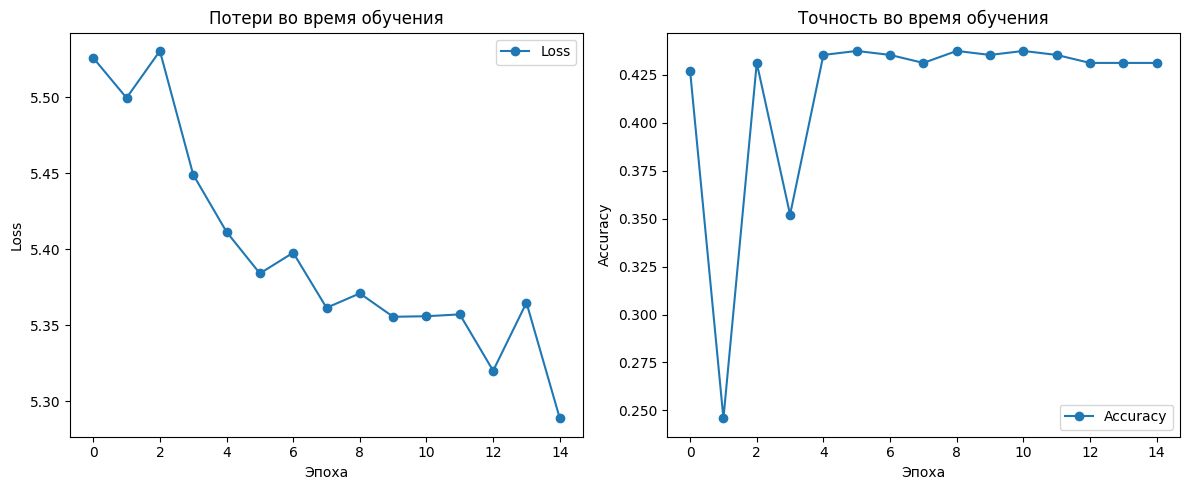

In [103]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses, marker='o', label='Loss')
plt.title('Потери во время обучения')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracies, marker='o', label='Accuracy')
plt.title('Точность во время обучения')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [107]:
for i in range(5):
    print(f"{i+1}: {ds['train']['text'][i][:200]}") #возьму в промт похожий текст из 2

1: I have just returned from a visit to my landlordthe solitary neighbour that I shall be troubled with. This is certainly a beautiful country! In all England, I do not believe that I could have fixed on
2: Stately, plump Buck Mulligan came from the stairhead, bearing a bowl of lather on which a mirror and a razor lay crossed. A yellow dressinggown, ungirdled, was sustained gently behind him on the mild 
3: To S.L.O., an American gentleman in accordance with whose classic taste the following narrative has been designed, it is now, in return for numerous delightful hours, and with the kindest wishes, dedi
4: 'But who shall dwell in these worlds if they be inhabited? . . . Are we or they Lords of the World? . . . And how are all things made for man?' KEPLER (quoted in The Anatomy of Melancholy) No one woul
5: Note See also 'The Republic by Plato, Jowett, eBook  The Republic of Plato is the longest of his works with the exception of the Laws, and is certainly the greatest of them. There a

In [108]:
PROMPT = "Stately, plump Buck Mulligan came from the stairhead, bearing a bowl of lather"

def generate(prompt, model, tokenizer, max_len=50):
    model.eval()
    tokens = tokenizer.encode(prompt, return_tensors="pt").to(device)

    for _ in range(max_len):
        last_token = tokens[:, -1].unsqueeze(1)
        logits = model(last_token)
        next_token = torch.argmax(logits, dim=-1)
        tokens = torch.cat([tokens, next_token.unsqueeze(1)], dim=1)

    return tokenizer.decode(tokens[0], skip_special_tokens=True)

generated_text = generate(PROMPT, model, tokenizer)
def print_generated_text(text, words_per_line=5):
    words = text.split()
    for i in range(0, len(words), words_per_line):
        print(" ".join(words[i:i + words_per_line]))

print("Generated Text:\n")
print_generated_text(generated_text, words_per_line=5)

Generated Text:

Stately, plump Buck Mulligan came
from the stairhead, bearing a
bowl of latheryyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyy


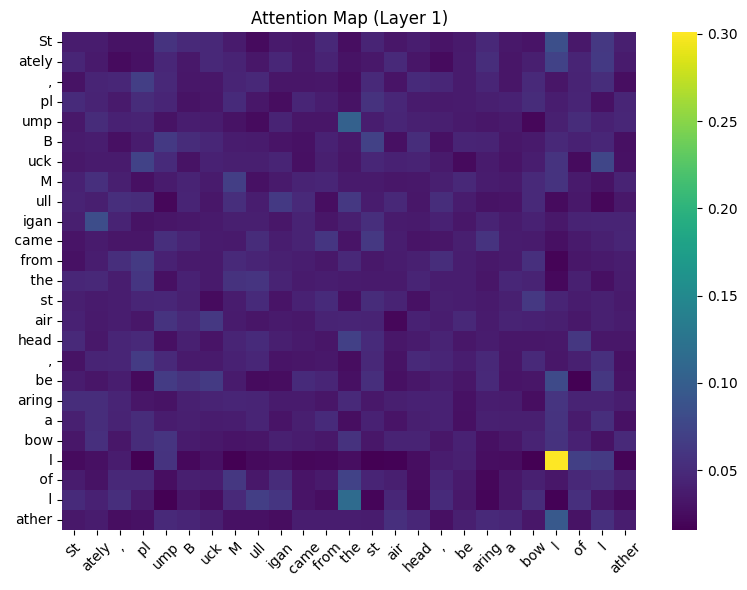

In [109]:
sample_input = tokenizer(PROMPT, return_tensors="pt")["input_ids"].to(device)
model(sample_input)
attn_weights = model.attention_weights[0][0].detach().cpu().numpy()
if attn_weights.ndim == 3:
    attn_weights = attn_weights.mean(axis=0)

tokens = tokenizer.convert_ids_to_tokens(sample_input[0])
tokens_readable = [tokenizer.convert_tokens_to_string([t]) for t in tokens]

plt.figure(figsize=(8, 6))
sns.heatmap(attn_weights, xticklabels=tokens_readable, yticklabels=tokens_readable, cmap="viridis")
plt.title("Attention Map (Layer 1)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Я обучила простую модель трансформера на литературном тексте из датасета ACOSharma/literature. Модель способна обрабатывать последовательности токенов и предсказывать следующий токен на основе контекста.

Визуализация весов внимания первого слоя показала, что каждый токен распределяет внимание неравномерно:

Токены почти ни на что не обращают внимание, но возможно выдеить еле заметные связи с соседними словами)

Модель также связывает отдалённые токены(немного утрированно сказано, но голубой чуть-чуть есть), если они морфологически или грамматически связаны, что демонстрирует способность учитывать частично глобальный контекст.

В результате можем сделать вывод о том, что модель должна воспринимать текст как последовательность взаимосвязанных элементов, объединяя локальные и ключевые глобальные зависимости для построения осмысленных продолжений текста. При принятии решений о следующем токене она должна опираться как на ближайшие слова, так и на морфологические/синтаксические связи в предложении, но визуально это не всё выполнилось.
